In [1]:
import qiskit
print(qiskit.__version__)

2.5.1


# AML23703 – Quantum Computing

# Tutorial 1: Introduction to Quantum Computing and Qiskit Environment Setup

---
**Name:** Mythri R

**USN:** 1GA23AI027

**Department:** Artificial Intelligence and Machine Learning

**Semester:** VII

**Course Code:** AML23703

**Date:** 24-07-2026

## Objective

The objective of this tutorial is to install Qiskit, verify the installation, understand the basics of quantum computing, create simple quantum circuits, visualize quantum states, and compare quantum randomness with classical randomness.

## Theory

Quantum computing uses qubits instead of classical bits.

Unlike classical bits, qubits can exist in a superposition of both 0 and 1 simultaneously.

Qiskit is IBM's open-source software development kit used for designing, simulating, and executing quantum circuits.

# Import Required Libraries

In [3]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_city
)

# Exercise 1 Easy
## Verify Qiskit Installation

In [4]:
print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()
print(simulator)

Qiskit Version: 2.5.1
AerSimulator('aer_simulator')


## Observation
The installed version of Qiskit was successfully detected and the Aer simulator was available for executing quantum circuits.

# Exercise 2 Medium
## One-Qubit Superposition using Hadamard Gate

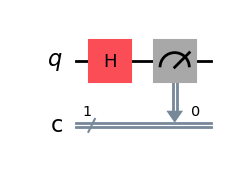

In [6]:
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)
qc.draw("mpl")

In [7]:
simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()
counts

{'1': 507, '0': 517}

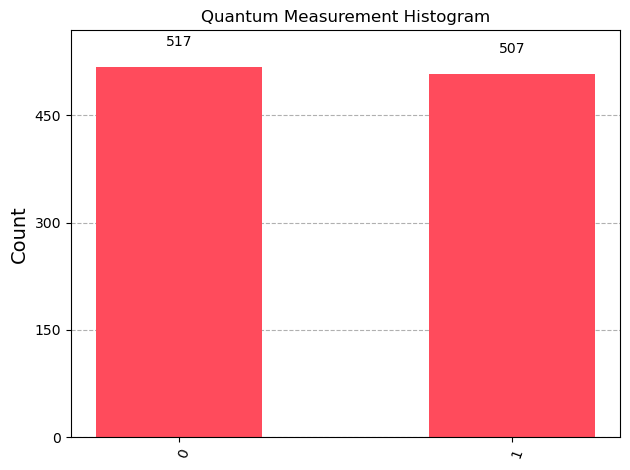

In [8]:
plot_histogram(
    counts,
    color=["#ff4b5c","#0096ff"],
    title="Quantum Measurement Histogram"
)

## Observation
The Hadamard gate placed the qubit into a superposition state, producing nearly equal probabilities for 0 and 1.

# Exercise 3 Hard
## Three-Qubit Superposition

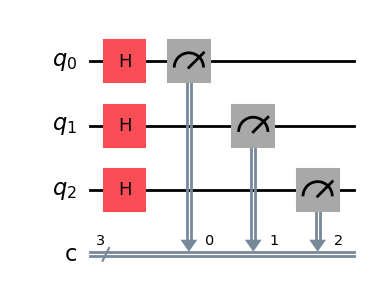

In [9]:
qc3 = QuantumCircuit(3,3)
qc3.h([0,1,2])
qc3.measure([0,1,2],[0,1,2])
qc3.draw("mpl")

In [10]:
job = simulator.run(qc3,shots=4096)
result = job.result()
counts = result.get_counts()
counts

{'010': 509,
 '101': 523,
 '110': 510,
 '001': 502,
 '011': 519,
 '000': 504,
 '111': 520,
 '100': 509}

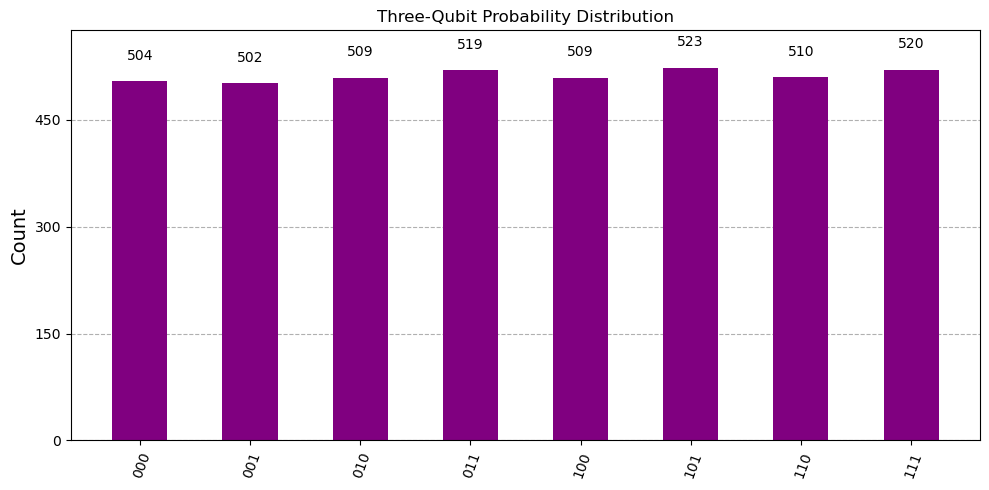

In [11]:
plot_histogram(
    counts,
    figsize=(10,5),
    color="purple",
    title="Three-Qubit Probability Distribution"
)

## Observation
All eight possible quantum states appeared with approximately equal probability, confirming the expected superposition.

# Exercise 4
## Quantum Random Number Generator

In [12]:
from random import randint
python_random = [randint(0,1) for _ in range(100)]

In [13]:
quantum_random = []
for i in range(100):
    qc = QuantumCircuit(1,1)
    qc.h(0)
    qc.measure(0,0)
    job = simulator.run(qc,shots=1)
    result = job.result()
    counts = result.get_counts()
    quantum_random.append(int(list(counts.keys())[0]))

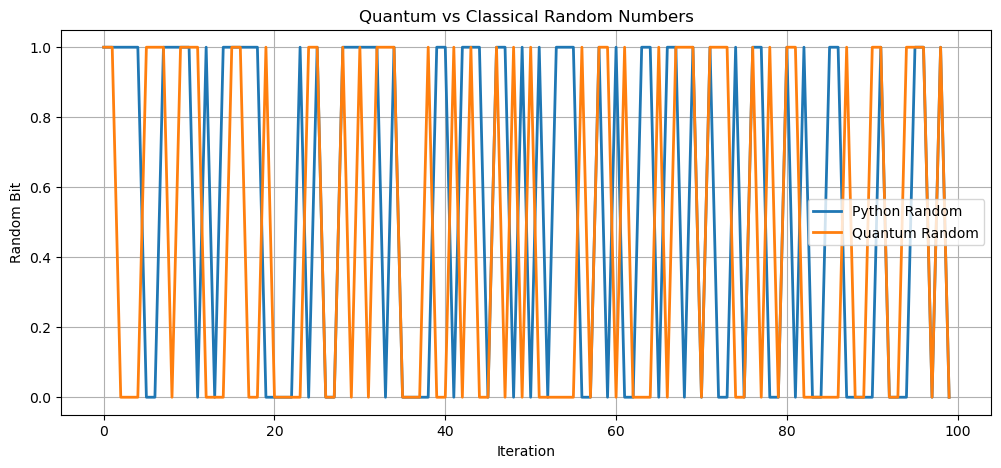

In [14]:
plt.figure(figsize=(12,5))
plt.plot(
    python_random,
    label="Python Random",
    linewidth=2
)
plt.plot(
    quantum_random,
    label="Quantum Random",
    linewidth=2
)
plt.title("Quantum vs Classical Random Numbers")
plt.xlabel("Iteration")
plt.ylabel("Random Bit")
plt.legend()
plt.grid()
plt.show()

## Observation
Quantum-generated random numbers exhibit inherent randomness due to quantum measurement, whereas Python generates pseudo-random numbers using deterministic algorithms.

# Conclusion
The tutorial successfully demonstrated the installation of Qiskit, construction of basic quantum circuits, visualization of quantum superposition, and implementation of a quantum random number generator. The results matched theoretical expectations.

# Reflection
### Question 1
The simulator produced results that closely matched the theoretical probability distribution. Minor differences were observed due to the finite number of measurement shots.

### Question 2
A classical probabilistic bit represents either 0 or 1 with a certain probability. A qubit, however, can exist in a superposition of both states simultaneously until it is measured.